In [1]:
%pip install -q "lightgbm>=4,<5" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "cloudpickle>=3,<4" "matplotlib>=3.8,<4" "kaggle>=1.7,<2"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 1.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
from __future__ import annotations

import json
import os
import subprocess
import time
from pathlib import Path

import cloudpickle
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb

WANDB_ENTITY = "kende23-n-a"
WANDB_PROJECT = "Walmart-Recruiting---Store-Sales-Forecasting"
REGISTRY_ARTIFACT_URI = "wandb-registry-model/Walmart_LightGBM_Pipeline:champion"
PIPELINE_FILENAME = "lightgbm_best_pipeline.pkl"

DATA_DIR_CANDIDATES = [
    Path("/content/drive/MyDrive/walmart_competition_data"),
    Path("/content/drive/My Drive/walmart_competition_data"),
    Path("/content/walmart_competition_data"),
    Path("data"),
    Path("../../data"),
]
OUTPUT_DIR = Path("/content/artifacts/lightgbm_inference") if Path("/content").exists() else Path("artifacts/lightgbm_inference")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUBMIT_TO_KAGGLE = False
KAGGLE_COMPETITION = "walmart-recruiting-store-sales-forecasting"
KAGGLE_MESSAGE = "W&B registered LightGBM pipeline"


In [4]:
def resolve_data_dir(candidates):
    required = ["test.csv", "features.csv", "stores.csv"]
    for candidate in candidates:
        if all((candidate / filename).exists() for filename in required):
            return candidate
    raise FileNotFoundError(
        "Could not find Walmart data directory with test.csv, features.csv, and stores.csv. "
        f"Checked: {[str(path) for path in candidates]}"
    )


DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES)
print(f"Using data directory: {DATA_DIR}")



Using data directory: /content/drive/MyDrive/walmart_competition_data


In [5]:
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features_raw = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores_raw = pd.read_csv(DATA_DIR / "stores.csv")

required_test_columns = ["Store", "Dept", "Date", "IsHoliday"]
if test_raw.columns.tolist() != required_test_columns:
    raise ValueError(f"Expected test columns {required_test_columns}, got {test_raw.columns.tolist()}")
if test_raw.duplicated(["Store", "Dept", "Date"]).any():
    raise ValueError("test.csv contains duplicate Store/Dept/Date rows")

# New LightGBM registry artifacts accept raw test.csv and merge stored features/stores inside the pipeline.
# Keep a merged fallback for older artifacts that were registered before the raw-input contract was added.
test_merged = test_raw.merge(stores_raw, on="Store", how="left")
test_merged = test_merged.merge(features_raw, on=["Store", "Date", "IsHoliday"], how="left")
test_merged["Weekly_Sales"] = np.nan

test_profile = {
    "test_rows": int(len(test_raw)),
    "test_weeks": int(test_raw["Date"].nunique()),
    "test_start": str(test_raw["Date"].min().date()),
    "test_end": str(test_raw["Date"].max().date()),
    "test_holiday_rows": int(test_raw["IsHoliday"].sum()),
}
display(pd.Series(test_profile, name="value").to_frame())
display(test_raw.head())



,value
test_rows,115064
test_weeks,39
test_start,2012-11-02
test_end,2013-07-26
test_holiday_rows,8928


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


## Download registered LightGBM pipeline


In [7]:
try:
    from google.colab import userdata
    wandb_api_key = userdata.get("WANDB_API_KEY")
except Exception:
    wandb_api_key = os.environ.get("WANDB_API_KEY")

wandb.login(key=wandb_api_key, relogin=False) if wandb_api_key else wandb.login()

run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    job_type="lightgbm_inference",
    name="LightGBM_Registry_Inference_Submission",
    tags=["lightgbm", "inference", "registry", "kaggle-submission"],
    config={
        "registry_artifact": REGISTRY_ARTIFACT_URI,
        "pipeline_filename": PIPELINE_FILENAME,
        "data_dir": str(DATA_DIR),
        "submit_to_kaggle": SUBMIT_TO_KAGGLE,
        **test_profile,
    },
)

model_artifact = run.use_artifact(REGISTRY_ARTIFACT_URI)
artifact_dir = Path(model_artifact.download(root=str(OUTPUT_DIR / "registry_model")))
pipeline_candidates = list(artifact_dir.rglob(PIPELINE_FILENAME))
if len(pipeline_candidates) != 1:
    raise FileNotFoundError(f"Expected one {PIPELINE_FILENAME}, found {pipeline_candidates}")

pipeline_path = pipeline_candidates[0]
with pipeline_path.open("rb") as file:
    pipeline = cloudpickle.load(file)

if not hasattr(pipeline, "feature_pipeline") or not hasattr(pipeline, "model"):
    raise TypeError("Registered artifact does not look like the expected LightGBM pipeline bundle.")

artifact_info = {
    "artifact_name": model_artifact.name,
    "artifact_version": model_artifact.version,
    "pipeline_path": str(pipeline_path),
    "selected_features": int(len(pipeline.selected_features)),
    "validation_weighted_mae": float(getattr(pipeline, "validation_weighted_mae", np.nan)),
}
display(pd.Series(artifact_info, name="value").to_frame())


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: Downloading large artifact 'Walmart_LightGBM_Pipeline:champion', 71.01MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:00.2 (359.5MB/s)


,value
artifact_name,Walmart_LightGBM_Pipeline:champion
artifact_version,v4
pipeline_path,/content/artifacts/lightgbm_inference/registry...
selected_features,80
validation_weighted_mae,1567.704469


In [11]:
started_at = time.perf_counter()
try:
    predictions = pipeline.predict(test_raw)
    pipeline_input_mode = "raw_test_csv"
except Exception as raw_error:
    print(f"Raw test prediction failed, falling back to merged test rows: {raw_error}")
    predictions = pipeline.predict(test_merged)
    pipeline_input_mode = "merged_test_with_external_tables"
prediction_seconds = time.perf_counter() - started_at

predictions = np.asarray(predictions, dtype="float64")
if predictions.shape != (len(test_raw),):
    raise ValueError(f"Prediction shape mismatch: {predictions.shape}")
if not np.isfinite(predictions).all():
    raise ValueError("Predictions contain non-finite values")

predictions = np.clip(predictions, 0.0, None)

prediction_stats = {
    "inference/prediction_seconds": float(prediction_seconds),
    "inference/submission_rows": int(len(predictions)),
    "inference/prediction_min": float(predictions.min()),
    "inference/prediction_mean": float(predictions.mean()),
    "inference/prediction_max": float(predictions.max()),
    "inference/prediction_std": float(predictions.std()),
    "inference/pipeline_input_mode": pipeline_input_mode,
}
run.log(prediction_stats)
run.summary.update(prediction_stats)
display(pd.Series(prediction_stats, name="value").to_frame())



/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


,value
inference/prediction_seconds,24.238987
inference/submission_rows,115064
inference/prediction_min,0.0
inference/prediction_mean,16326.503921
inference/prediction_max,220841.224986
inference/prediction_std,22697.051461
inference/pipeline_input_mode,raw_test_csv


## Create Kaggle submission


In [10]:
submission = pd.DataFrame({
    "Id": (
        test_raw["Store"].astype(str)
        + "_"
        + test_raw["Dept"].astype(str)
        + "_"
        + test_raw["Date"].dt.strftime("%Y-%m-%d")
    ),
    "Weekly_Sales": predictions,
})

if submission["Id"].duplicated().any():
    raise ValueError("Submission contains duplicate Id values")
if submission["Weekly_Sales"].isna().any():
    raise ValueError("Submission contains missing predictions")

submission_path = OUTPUT_DIR / "submission_lightgbm_registry.csv"
manifest_path = OUTPUT_DIR / "lightgbm_inference_manifest.json"
submission.to_csv(submission_path, index=False)

manifest = {
    **artifact_info,
    **prediction_stats,
    "registry_artifact": REGISTRY_ARTIFACT_URI,
    "submission_path": str(submission_path),
    "created_at_utc": pd.Timestamp.utcnow().isoformat(),
    "competition": KAGGLE_COMPETITION,
}
manifest_path.write_text(json.dumps(manifest, indent=2, default=str))

print(f"Submission saved to: {submission_path}")
display(submission.head())


Submission saved to: /content/artifacts/lightgbm_inference/submission_lightgbm_registry.csv


,Id,Weekly_Sales
0,1_1_2012-11-02,39158.313008
1,1_1_2012-11-09,20525.682348
2,1_1_2012-11-16,20190.249132
3,1_1_2012-11-23,23824.713871
4,1_1_2012-11-30,25090.533808


## Log diagnostics and submission artifact


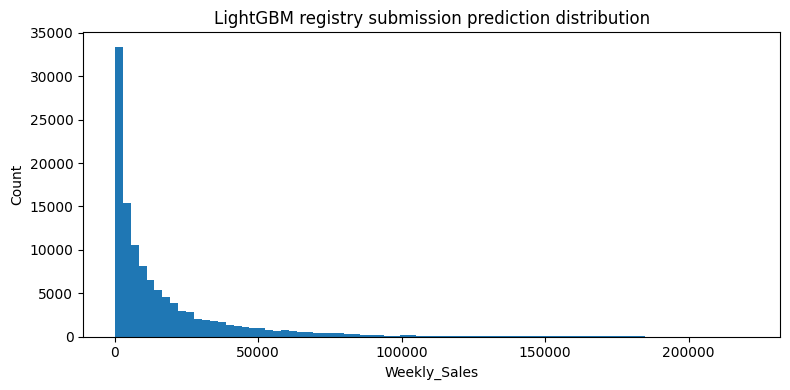

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(submission["Weekly_Sales"], bins=80)
ax.set_title("LightGBM registry submission prediction distribution")
ax.set_xlabel("Weekly_Sales")
ax.set_ylabel("Count")
plt.tight_layout()
hist_path = OUTPUT_DIR / "lightgbm_prediction_histogram.png"
fig.savefig(hist_path, dpi=160)
plt.show()

submission_artifact = wandb.Artifact(
    "lightgbm-kaggle-submission",
    type="submission",
    description="Kaggle submission generated from the W&B Registry LightGBM pipeline.",
    metadata=manifest,
)
submission_artifact.add_file(str(submission_path))
submission_artifact.add_file(str(manifest_path))
submission_artifact.add_file(str(hist_path))
run.log_artifact(submission_artifact, aliases=["latest"])

run.log({
    "inference/submission_preview": wandb.Table(dataframe=submission.head(2000)),
    "inference/prediction_histogram": wandb.Image(str(hist_path)),
})
for key, value in manifest.items():
    run.summary[key] = value


In [13]:
run.finish()
print("Inference complete: registry LightGBM model -> test set -> submission artifact.")


inference/prediction_max,▁▁▁
inference/prediction_mean,▁▁▁
inference/prediction_min,▁▁▁
inference/prediction_seconds,▁█▄
inference/prediction_std,▁▁▁
inference/submission_rows,▁▁▁
artifact_name,Walmart_LightGBM_Pip...
artifact_version,v4
competition,walmart-recruiting-s...
created_at_utc,2026-07-11T22:29:02....
inference/pipeline_input_mode,raw_test_csv


Inference complete: registry LightGBM model -> test set -> submission artifact.
